## Neural Network built from scratch using Numpy  



В ноутбуке протестируем нейронный модуль сети, созданный на библиотеке Numpy (nn.py), который работает в некоторых задачах нелинейной классификации.  


Мы будем обучать нейросеть в течение нескольких эпох и с некоторыми гиперпараметрами
Построим границу принятия решений в реальном времени
Построим показатели обучения и проверки, такие как потери и точность  


Модель бинарной классификации — она моделирует зависимость между координатами точки и её классом.  
1. 	Разделение точек по двум кластерам (Линейная граница)
2. 	Разделение внутреннего круга и внешнего кольца (Кольцевая граница)
3.  XOR — 4 области, 2 из них относятся к одному классу (Сложная нелинейная)  

Создадим конуретную архитектуру модели, где входной слой: 2 нейрона (x и y), скрытый слой: 4 нейрона, выходной слой: 1 нейрон (даёт вероятность).  

Такая модель обучается на данных: сравнивает выход с правильной меткой, вычисляет ошибку и с помощью градиентного спуска меняет веса. После обучения модель может предсказывать класс новой точки по её координатам.

**Для чего программа**  
Генерирует данные (искусственно, чтобы тренировать модели): простые (make_blobs), сложные (make_circles), XOR-подобные (generate_points)  

Создаёт нейронные сети с разной архитектурой. Обучает эти сети, чтобы они научились разделять точки по классам. Учимся аппроксимировать и моделировать зависимости.

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import nn

In [3]:
def plot_history(history):
    n = history['epochs']
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    n = 4000

    plt.plot(range(history['epochs'])[:n], history['train_loss'][:n], label='train_loss')
    plt.plot(range(history['epochs'])[:n], history['test_loss'][:n], label='test_loss')
    plt.title('train and test loss')
    plt.grid(1)
    plt.xlabel('epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(history['epochs'])[:n], history['train_acc'][:n], label='train_acc')
    plt.plot(range(history['epochs'])[:n], history['test_acc'][:n], label='test_acc')
    plt.title('train & test accuracy')
    plt.grid(1)
    plt.xlabel('epochs')
    plt.legend()

# Linear problem

Архитектура: [2, 4, 4, 1] — входной слой (2 признака), два скрытых слоя по 4 нейрона, выходной — 1 (классификация).  
learning_rate=0.4: довольно высокий, но при малой глубине сработает.  
plot_every=10: каждые 10 эпох рисуется область принятия решения (decision boundary).

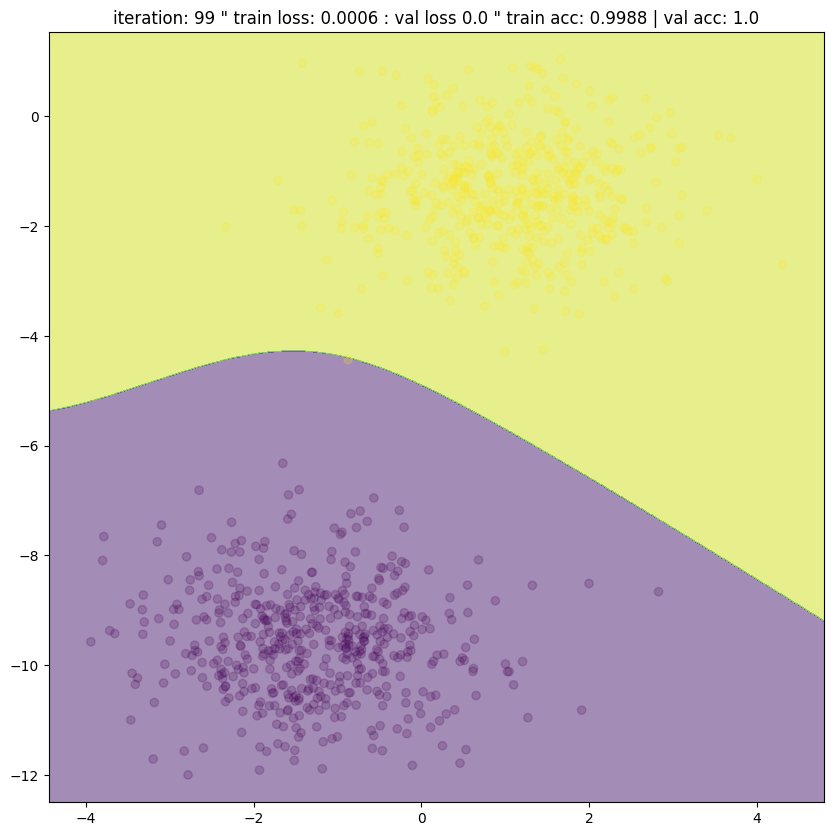

In [4]:
# Линейно разделимая выборка
"""make_blobs: генерирует точки, сгруппированные вокруг заданного числа центров — это линейно разделимая задача классификации"""

data = datasets.make_blobs(n_samples=1000, centers=2, random_state=2)
X = data[0].T
y = np.expand_dims(data[1], 1).T

neural_net = nn.NeuralNetwork([2, 4, 4, 1], seed=0)
history = neural_net.train(X=X, y=y, batch_size=16, epochs=100, learning_rate=0.4, print_every=200, validation_split=0.2, tqdm_=False, plot_every=10)

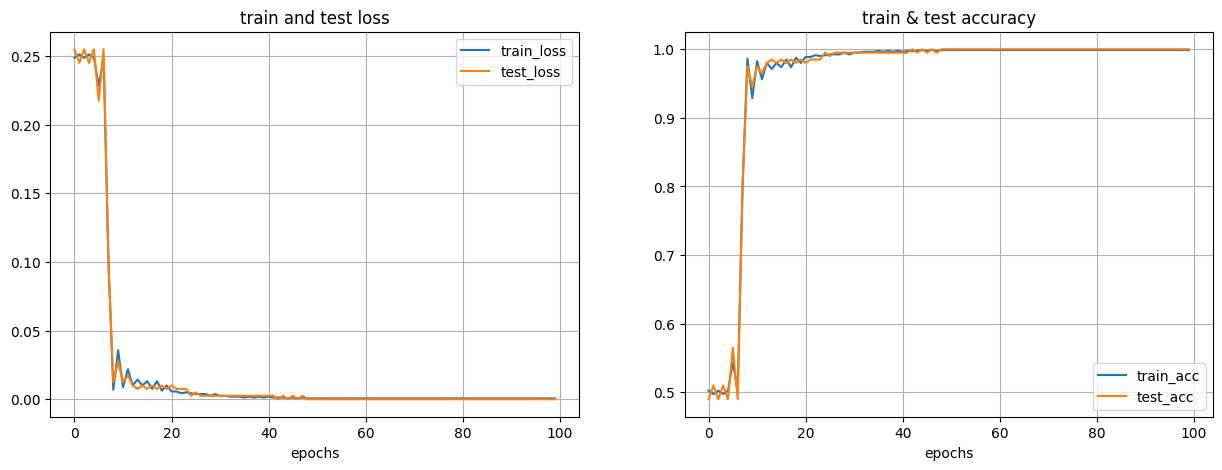

In [5]:
plot_history(history)

Архитектура: [2, 4, 1] — 1 скрытый слой. Несмотря на небольшую глубину, можно уловить сложную границу, т.к. используются нелинейные активации.  

epochs=1200: требуется больше эпох, т.к. задача сложнее (нелинейная граница между классами).

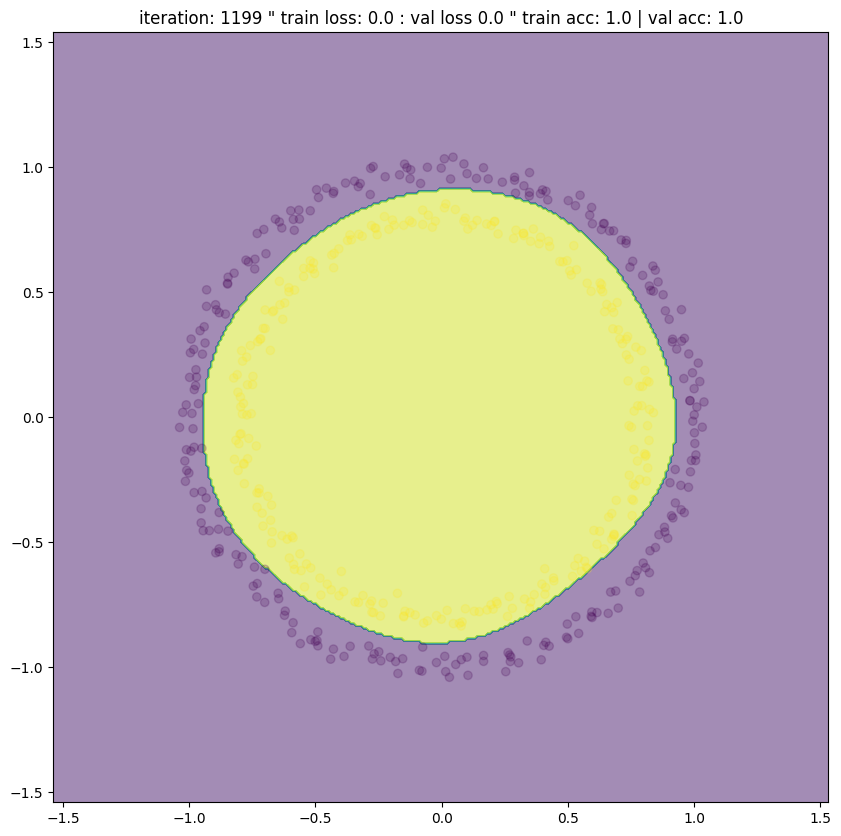

In [6]:
# Нелинейно разделимая выборка
"""make_circles: создаёт данные, где точки одного класса находятся внутри круга, а другого — вокруг него. 
Это классический пример нелинейной задачи."""

data = datasets.make_circles(n_samples=500, noise=0.025)
X = data[0].T
y = np.expand_dims(data[1], 1).T

neural_net = nn.NeuralNetwork([2, 4, 1], seed=11)
history = neural_net.train(X=X, y=y, batch_size=16, epochs=1200, learning_rate=0.4, 
    print_every=200, validation_split=0.2, tqdm_=False, plot_every=50)

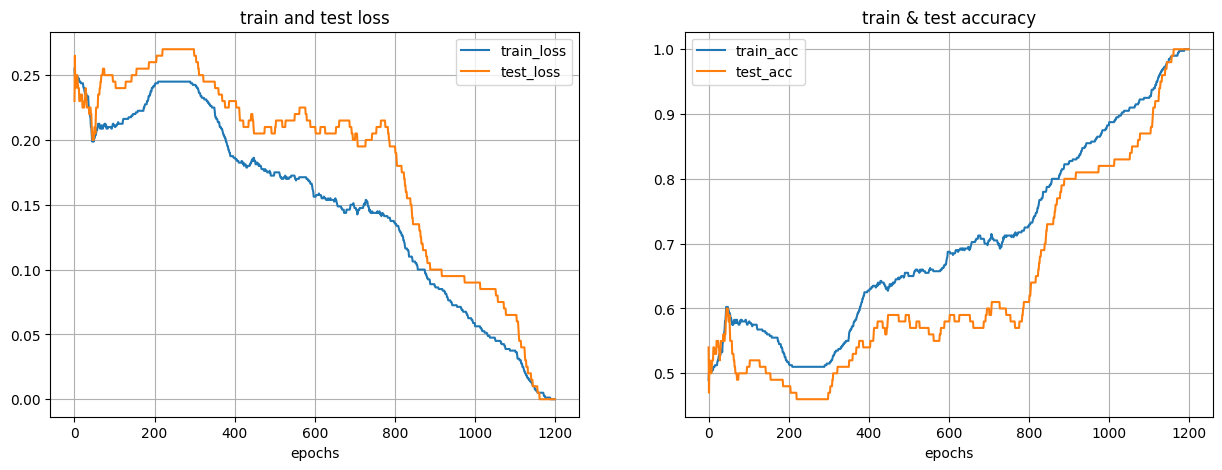

In [7]:
plot_history(history)

## XOR problem  

Генерирует точки с шумом вокруг заданных центров.  

centers: список координат центров классов.  
labels: к какому классу принадлежит каждая группа.  
amplitude: параметр не используется (возможно, задуман как коэффициент шума, но в коде не применяется).

In [8]:
# Генерация собственных точек (для XOR-подобной задачи)

def generate_points(n, centers, labels, amplitude):
    x1_noisy = []
    x2_noisy = []
    y = []

    for center, c in zip(centers, labels):
        x1, x2 = center
        noisy_x1 = np.random.rand(n)
        noisy_x2 = np.random.rand(n)
        x1_noisy += (noisy_x1 + x1).tolist()
        x2_noisy += (noisy_x2 + x2).tolist()
        y += [c] * n

    X = list(zip(x1_noisy, x2_noisy))
    X = np.array(X)
    y = np.array(y)
    y = np.expand_dims(y, 1)

    X = X.T
    y = y.T

    return X, y

X, y = generate_points(500, [(0, 0), (0, 1), (1, 0), (1, 1)], [0, 1, 1, 0], 0.005)

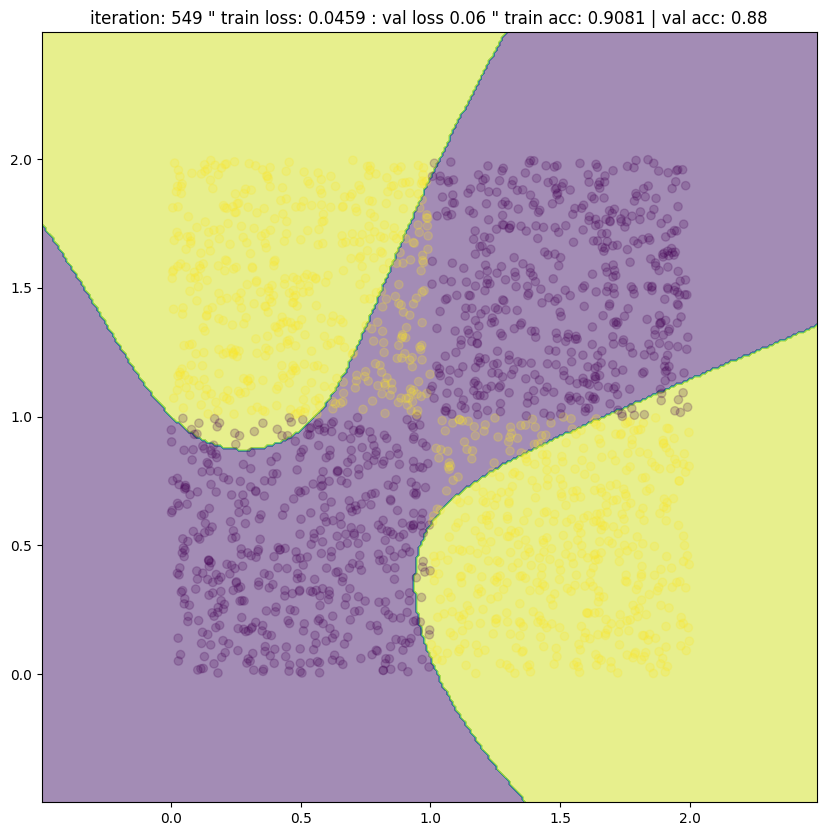

In [9]:
neural_net = nn.NeuralNetwork([2, 4, 1], seed=3)
history = neural_net.train(X=X, y=y, batch_size=64, epochs=550, learning_rate=0.2,
    print_every=200, validation_split=0.2, tqdm_=False, plot_every=25)

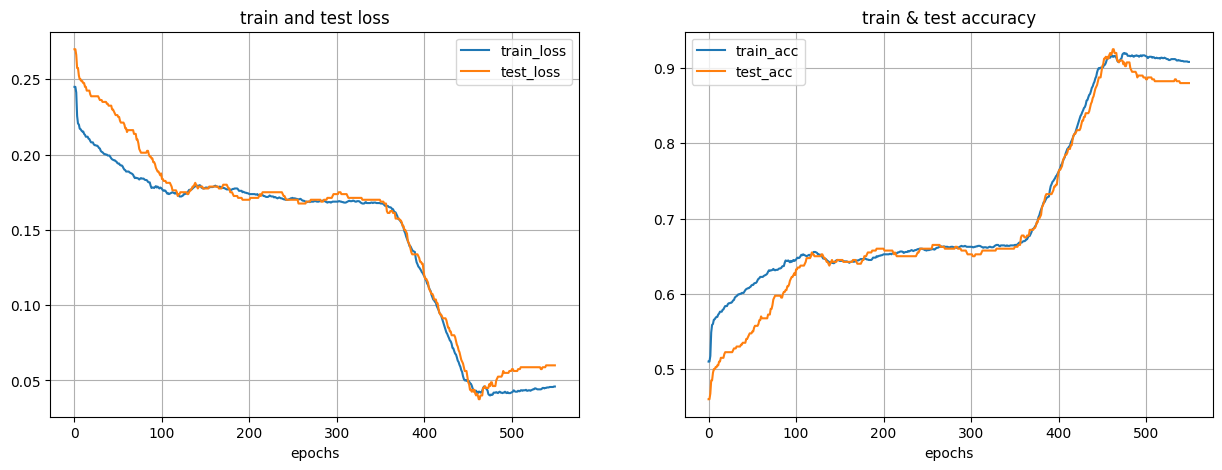

In [10]:
plot_history(history)